# Archaeological Site Risk Analysis in Marmarica

This notebook explores the spatial distribution and recorded risk levels of **3,355 archaeological and cultural heritage sites** across the Marmarica region of northeastern Libya and northwestern Egypt.

The workflow covers data-quality assessment, coordinate reconstruction, label verification, exploratory spatial analysis, categorical association analysis, and a comparison between decision-tree regression and classification. The analysis is exploratory and is not intended for operational heritage-risk decision-making.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = REPO_ROOT / "data" / "raw" / "Marmarica_sites.csv"
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
RESULTS_DIR = REPO_ROOT / "results"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


## 1. Data Loading and Initial Inspection

In [2]:
#The dataset was provided as a CSV file but uses semicolons as delimiters. Therefore, the Python parsing engine with a custom separator was used to successfully load the data.
df = pd.read_csv(DATA_PATH, sep=";", engine="python") 
print("Shape:", df.shape)

Shape: (3355, 18)


In [3]:
df.head()

,Zone,ID,Modern_Name,Old_Name,Coord_x,Coord_y,Accuracy,Validation,Type,Subtype,Eco_Zone,Risk_level,Cod_Risk,Remains,Chronology,Keywords,Descriptio,Biblio_ref
0,2,PE_00001,Bir Abd el Wahid,Unknown,28.173.482,30.977.778,High,3,Water place,Cistern,Coastal zone and northern tableland,High,5,No,Undetermined,"Cistern, Eastern Marmarica","Not surveyed, Digitization based on satellite ...","U.S. Defense Mapping Agency Aerospace Center, ..."
1,2,PE_00002,Bates`s Island,Unknown,27.266.849,31.361.078,High,4,Settlement,Harbour,Coastal zone and northern tableland,High,"2, 3, 4",Yes,"Late Bronze Age, Early Iron Age, Archaic, Clas...","Marmarica coast, Marsa Matruh, Shells, Cannani...","Island settlement, Crete, which lies ca, 420 k...","(White, D, 1986: 51-84);"
2,2,PE_00003,Marsa Matruh,"Amunia, Paraetonium",27.236.845,31.350.136,High,4,Settlement,Harbour,Coastal zone and northern tableland,High,6,Yes,"Late Bronze Age, Early Iron Age, Archaic, Clas...","Marsa Matruh, City, Aegean trade, Eastern Mar...",Digitization based on satellite imagery and ca...,"(White, D, 2002); https://pleiades,stoa,org/pl..."
3,2,PE_00004,Zawiyet Umm el - Rakham,Unknown,27.025.833,31.4,High,4,Settlement,Fort,Coastal zone and northern tableland,High,"4, 5, 6",Yes,Late Bronze Age,"New Kingdom, Ramesside period, Cannanite ampho...","Located on the Marmarica coast of Egypt, 20km ...","(Snape, S, 2001: 19-20);http://vici,org/vici/2..."
4,2,PE_00005,Unknown,Unknown,25.993.963,31.590.845,Intermediate,2,Burial place,Grave(s),Coastal zone and northern tableland,High,5,No,Undetermined,"Grave(s), Eastern Marmarica","Not surveyed, Digitization based on satellite ...","U.S. Defense Mapping Agency Aerospace Center, ..."


## 2. Data Quality Assessment

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3355 entries, 0 to 3354
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Zone         3355 non-null   int64 
 1   ID           3355 non-null   object
 2   Modern_Name  3355 non-null   object
 3   Old_Name     3355 non-null   object
 4   Coord_x      3355 non-null   object
 5   Coord_y      3355 non-null   object
 6   Accuracy     3355 non-null   object
 7   Validation   3355 non-null   int64 
 8   Type         3355 non-null   object
 9   Subtype      3355 non-null   object
 10  Eco_Zone     3355 non-null   object
 11  Risk_level   3355 non-null   object
 12  Cod_Risk     3355 non-null   object
 13  Remains      3355 non-null   object
 14  Chronology   3355 non-null   object
 15  Keywords     3355 non-null   object
 16  Descriptio   3355 non-null   object
 17  Biblio_ref   3355 non-null   object
dtypes: int64(2), object(16)
memory usage: 471.9+ KB


### 2.1 Column profile

In [5]:
data_profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "unique_values": df.nunique(),
    "missing_values": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
})

data_profile


,dtype,unique_values,missing_values,missing_percent
Zone,int64,2,0,0.0
ID,object,3354,0,0.0
Modern_Name,object,1114,0,0.0
Old_Name,object,36,0,0.0
Coord_x,object,3354,0,0.0
Coord_y,object,3351,0,0.0
Accuracy,object,3,0,0.0
Validation,int64,4,0,0.0
Type,object,4,0,0.0
Subtype,object,11,0,0.0


### 2.2 Missing and placeholder values

In [6]:
length = len(df)

for column in df.columns:
    percent_NaN = df[column].isna().sum()/length*100 
    print('-------')
    print(column)
    print(percent_NaN)

-------
Zone
0.0
-------
ID
0.0
-------
Modern_Name
0.0
-------
Old_Name
0.0
-------
Coord_x
0.0
-------
Coord_y
0.0
-------
Accuracy
0.0
-------
Validation
0.0
-------
Type
0.0
-------
Subtype
0.0
-------
Eco_Zone
0.0
-------
Risk_level
0.0
-------
Cod_Risk
0.0
-------
Remains
0.0
-------
Chronology
0.0
-------
Keywords
0.0
-------
Descriptio
0.0
-------
Biblio_ref
0.0


In [7]:
cols_name = ['Modern_Name', 'Old_Name']

for col in cols_name:
    total = len(df)
    unknown = df[col].isin(['Unknown']).sum()
    ratio = unknown / total * 100
    print(f"{col}: {unknown}/{total} ({ratio:.2f}%) are unknown")

Modern_Name: 1869/3355 (55.71%) are unknown
Old_Name: 3318/3355 (98.90%) are unknown


In [8]:
total = len(df)
Undetermined = df['Chronology'].isin(['Undetermined']).sum()
ratio = Undetermined / total * 100
print(f"{Undetermined}/{total} ({ratio:.2f}%) are undetermined")

3214/3355 (95.80%) are undetermined


## 3. Feature Selection
'ID', 'Modern_Name', 'Old_Name' and 'Biblio_ref' were removed as they provide little analytical value.  
'Keywords'and 'Description' contain descriptive text and were therefore excluded.  
Although 'Chronology' could be relevant but 95.80% of its values are undetermined, so it was dropped.

In [9]:
df_new = df.drop(columns=['ID', 'Modern_Name', 'Old_Name', 'Chronology','Keywords','Descriptio', 'Biblio_ref'])

In [10]:
df_new.head()

,Zone,Coord_x,Coord_y,Accuracy,Validation,Type,Subtype,Eco_Zone,Risk_level,Cod_Risk,Remains
0,2,28.173.482,30.977.778,High,3,Water place,Cistern,Coastal zone and northern tableland,High,5,No
1,2,27.266.849,31.361.078,High,4,Settlement,Harbour,Coastal zone and northern tableland,High,"2, 3, 4",Yes
2,2,27.236.845,31.350.136,High,4,Settlement,Harbour,Coastal zone and northern tableland,High,6,Yes
3,2,27.025.833,31.4,High,4,Settlement,Fort,Coastal zone and northern tableland,High,"4, 5, 6",Yes
4,2,25.993.963,31.590.845,Intermediate,2,Burial place,Grave(s),Coastal zone and northern tableland,High,5,No


## 4. Coordinate Reconstruction and Validation
The Marmarica region is roughly bounded by lon 20–35 and lat 25–35.  
Therefore, valid coordinates should follow the pattern “25.xxxxxxx, 30.xxxxxxx”(lat, lon).  

Many records contain formatting errors (e.g., extra decimal points) and invalid values, so the coordinates need to be parsed and corrected.

In [11]:
def parse_coord(x):
    x_str = str(x) # ensure the value is a string
    clean_coord = [] # store valid characters
    for ch in x_str:
        if ch.isdigit() or ch == '.':  # keep numeric characters and decimal point
            clean_coord.append(ch)
    s = ''.join(clean_coord) #join characters to strings
            
    digits = s.replace('.', '') # remove all decimal points
    if len(digits) < 2: # the coordinate seems to be an error
        return np.nan
    return float(digits[:2] + '.' + digits[2:]) #insert the decimal point after the first two digits

df_new['lon'] = df_new['Coord_x'].apply(parse_coord)
df_new['lat'] = df_new['Coord_y'].apply(parse_coord)

df_new['coord_valid'] = df_new['lon'].between(20, 35) & df_new['lat'].between(25, 35) 

In [12]:
df_new.head(20)

,Zone,Coord_x,Coord_y,Accuracy,Validation,Type,Subtype,Eco_Zone,Risk_level,Cod_Risk,Remains,lon,lat,coord_valid
0,2,28.173.482,30.977.778,High,3,Water place,Cistern,Coastal zone and northern tableland,High,5,No,28.173482,30.977778,True
1,2,27.266.849,31.361.078,High,4,Settlement,Harbour,Coastal zone and northern tableland,High,"2, 3, 4",Yes,27.266849,31.361078,True
2,2,27.236.845,31.350.136,High,4,Settlement,Harbour,Coastal zone and northern tableland,High,6,Yes,27.236845,31.350136,True
3,2,27.025.833,31.4,High,4,Settlement,Fort,Coastal zone and northern tableland,High,"4, 5, 6",Yes,27.025833,31.400000,True
4,2,25.993.963,31.590.845,Intermediate,2,Burial place,Grave(s),Coastal zone and northern tableland,High,5,No,25.993963,31.590845,True
5,2,25.256.363,31.329.053,High,3,Water place,Cistern,Northern Marmarica Plateau,Moderate,2,No,25.256363,31.329053,True
6,2,2.515.357,31.552.736,Low,1,Settlement,Harbour,Coastal zone and northern tableland,Undetermined,1,Yes,25.153570,31.552736,True
7,2,25.374.562,31.043.162,High,3,Water place,Cistern,"Marmarica Plateau, full desert margin",Moderate,2,No,25.374562,31.043162,True
8,2,26.302.504,30.247.635,High,4,Water place,Cistern,Central Marmarica Plateau,High,6,Yes,26.302504,30.247635,True
9,2,25.363.654,3.142.593,High,3,Water place,Cistern,Coastal zone and northern tableland,Moderate,2,No,25.363654,31.425930,True


In [13]:
#check if the coordinates are correctly adjusted
df_new['coord_valid'].value_counts(normalize=True) * 100 


coord_valid
True    100.0
Name: proportion, dtype: float64

## 5. Feature and Target Preparation

### 5.1 Encode visible remains

In [14]:
df_new['Remains_bin'] = (df_new['Remains'].map({'Yes': 1, 'No': 0}))

In [15]:
df_new.head()

,Zone,Coord_x,Coord_y,Accuracy,Validation,Type,Subtype,Eco_Zone,Risk_level,Cod_Risk,Remains,lon,lat,coord_valid,Remains_bin
0,2,28.173.482,30.977.778,High,3,Water place,Cistern,Coastal zone and northern tableland,High,5,No,28.173482,30.977778,True,0
1,2,27.266.849,31.361.078,High,4,Settlement,Harbour,Coastal zone and northern tableland,High,"2, 3, 4",Yes,27.266849,31.361078,True,1
2,2,27.236.845,31.350.136,High,4,Settlement,Harbour,Coastal zone and northern tableland,High,6,Yes,27.236845,31.350136,True,1
3,2,27.025.833,31.4,High,4,Settlement,Fort,Coastal zone and northern tableland,High,"4, 5, 6",Yes,27.025833,31.400000,True,1
4,2,25.993.963,31.590.845,Intermediate,2,Burial place,Grave(s),Coastal zone and northern tableland,High,5,No,25.993963,31.590845,True,0


### 5.2 Verify and encode risk levels

The "Risk_level" feature contains four classes: High, Moderate, Low, and Undetermined.  
After reviewing the metadata, only three official risk levels are defined: High, Moderate, and Low. These levels are determined by the types of risks associated with each site, as recorded in "Cod_Risk".

"Undetermined" is a type of risk recorded as code 1, which is classified as Low in the metadata.

Therefore, the following steps were applied:
1. Verify that all sites with Cod_Risk = 1 have a Risk_level of either "Low" or "Undetermined".
2. Reassign all "Undetermined" values to "Low".

In [16]:
check = df_new[
    (df_new['Cod_Risk'] == '1') &
    (~df_new['Risk_level'].isin(['Low', 'Undetermined']))
]

len(check)

0

In [17]:
df_new.loc[(df_new['Risk_level'] == 'Undetermined') & (df_new['Cod_Risk'] == '1'), 'Risk_level'] = 'Low'

df_new['Risk_level'].value_counts()

Risk_level
Moderate    1741
High        1418
Low          196
Name: count, dtype: int64

In [18]:
# Encode ordinal categories 

risk_map = {
    'Low': 1,
    'Moderate': 2,
    'High': 3
}

df_new['Risk_numeric'] = df_new['Risk_level'].map(risk_map)

In [19]:
df_new.head()

,Zone,Coord_x,Coord_y,Accuracy,Validation,Type,Subtype,Eco_Zone,Risk_level,Cod_Risk,Remains,lon,lat,coord_valid,Remains_bin,Risk_numeric
0,2,28.173.482,30.977.778,High,3,Water place,Cistern,Coastal zone and northern tableland,High,5,No,28.173482,30.977778,True,0,3
1,2,27.266.849,31.361.078,High,4,Settlement,Harbour,Coastal zone and northern tableland,High,"2, 3, 4",Yes,27.266849,31.361078,True,1,3
2,2,27.236.845,31.350.136,High,4,Settlement,Harbour,Coastal zone and northern tableland,High,6,Yes,27.236845,31.350136,True,1,3
3,2,27.025.833,31.4,High,4,Settlement,Fort,Coastal zone and northern tableland,High,"4, 5, 6",Yes,27.025833,31.400000,True,1,3
4,2,25.993.963,31.590.845,Intermediate,2,Burial place,Grave(s),Coastal zone and northern tableland,High,5,No,25.993963,31.590845,True,0,3


## 6. Save the Analysis-Ready Dataset

In [20]:
df_new.to_csv(PROCESSED_DIR / "Marmarica_sites_analysis_ready.csv", index=False)


## 7. Exploratory Spatial Analysis

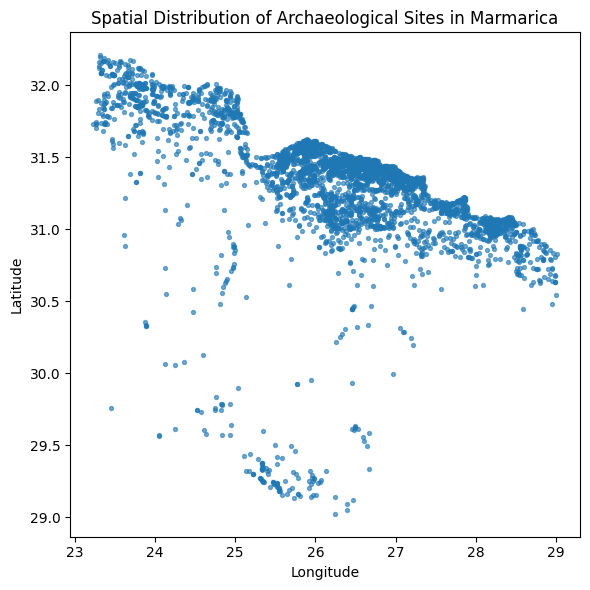

In [21]:

plt.figure(figsize=(6, 6))
plt.scatter(df_new['lon'], df_new['lat'], s=8, alpha=0.6)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Archaeological Sites in Marmarica")
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "site-spatial-distribution.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

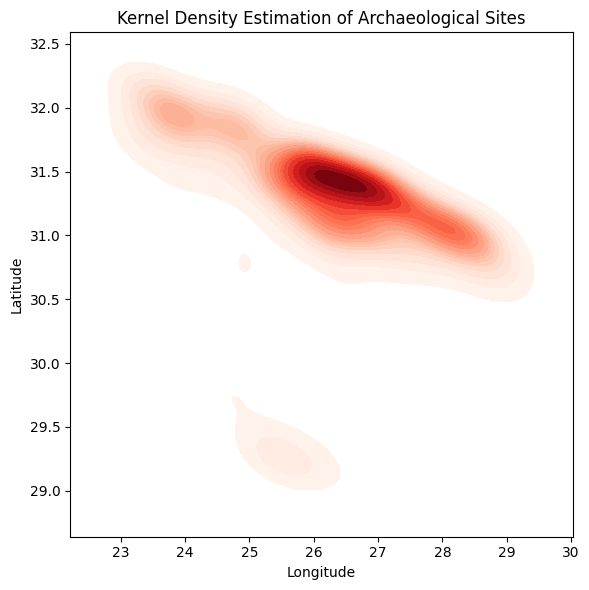

In [22]:
import seaborn as sns

plt.figure(figsize=(6, 6))

sns.kdeplot(
    x=df_new['lon'],
    y=df_new['lat'],
    fill=True,
    cmap='Reds',
    levels=20,
    thresh=0.05
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Kernel Density Estimation of Archaeological Sites")
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "site-density-kde.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

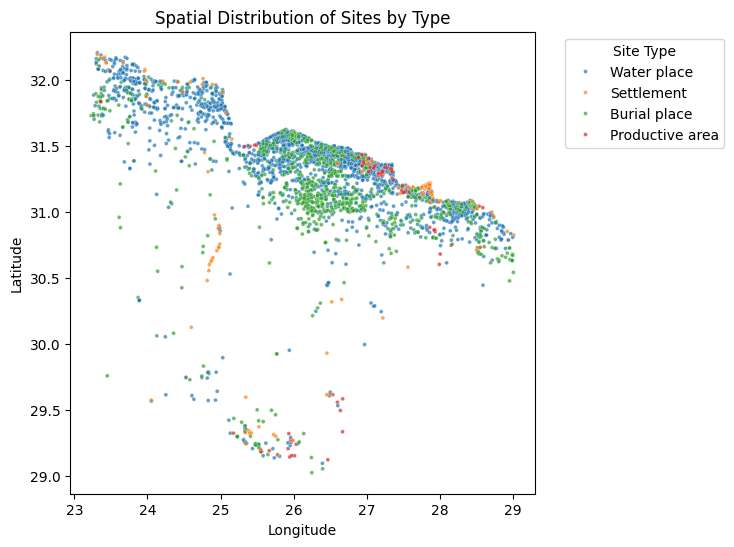

In [23]:
plt.figure(figsize=(6, 6))

sns.scatterplot(
    data=df_new,
    x='lon',
    y='lat',
    hue='Type',
    s=8,
    alpha=0.7
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Sites by Type")
plt.legend(title="Site Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

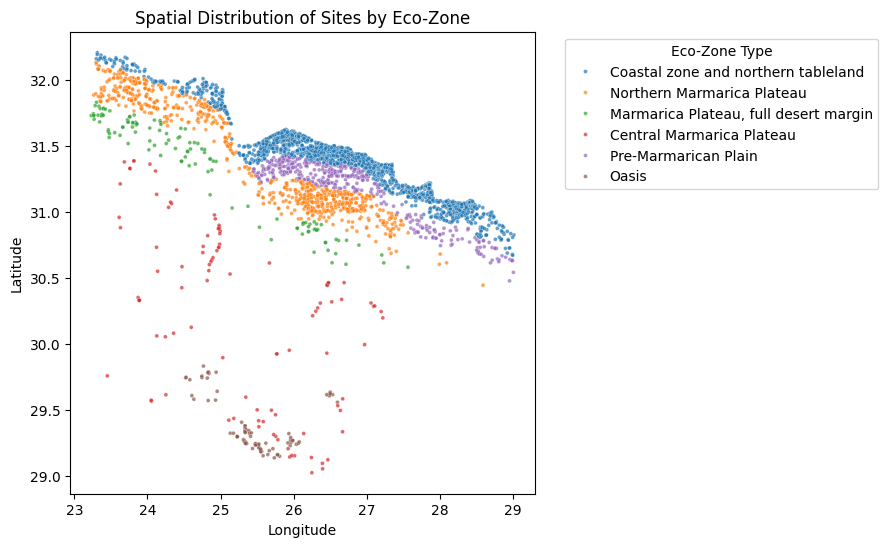

In [24]:
plt.figure(figsize=(6, 6))

sns.scatterplot(
    data=df_new,
    x='lon',
    y='lat',
    hue='Eco_Zone',
    s=8,
    alpha=0.7
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Sites by Eco-Zone")
plt.legend(title="Eco-Zone Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

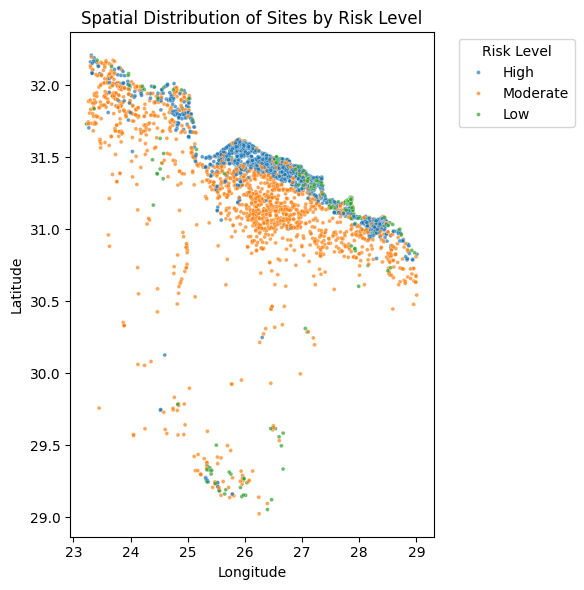

In [25]:
plt.figure(figsize=(6, 6))

sns.scatterplot(
    data=df_new,
    x='lon',
    y='lat',
    hue='Risk_level',
    s=8,
    alpha=0.7
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Sites by Risk Level")
plt.legend(title="Risk Level", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "risk-level-spatial-distribution.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

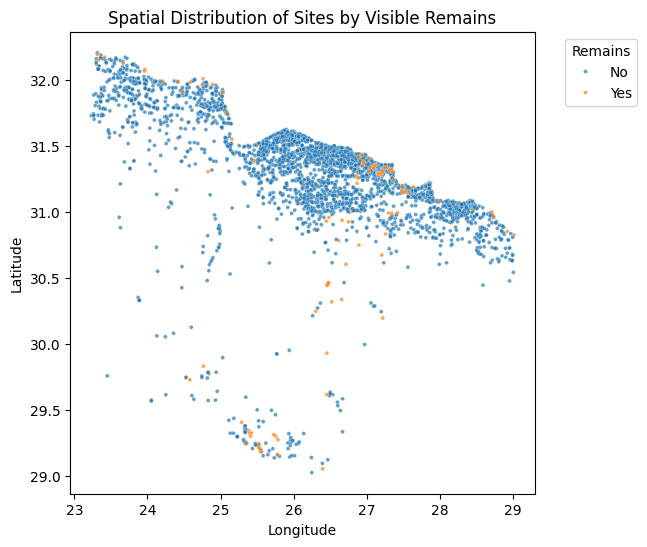

In [26]:
plt.figure(figsize=(6, 6))

sns.scatterplot(
    data=df_new,
    x='lon',
    y='lat',
    hue='Remains',
    s=8,
    alpha=0.7
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Sites by Visible Remains")
plt.legend(title="Remains", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

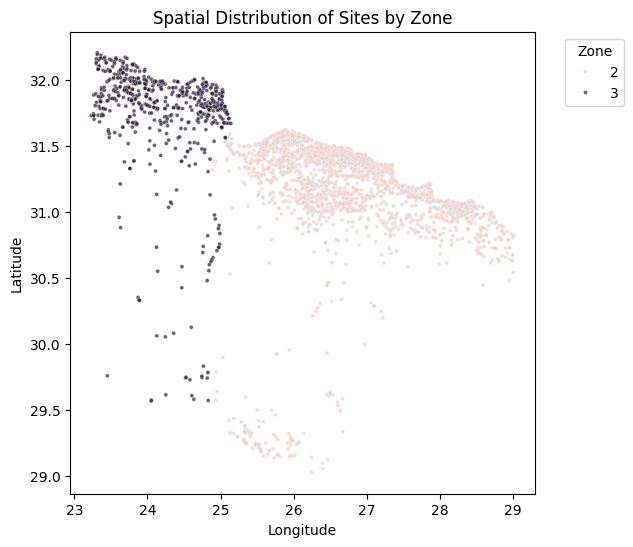

In [27]:
plt.figure(figsize=(6, 6))

sns.scatterplot(
    data=df_new,
    x='lon',
    y='lat',
    hue='Zone',
    s=8,
    alpha=0.7
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Sites by Zone")
plt.legend(title="Zone", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 8. Categorical Association Analysis
Explore the relationships between Type, Eco_Zone, Risk, and Remains by Cramér’s V corraltion heatmap.

In [28]:
features = ['Type','Eco_Zone','Risk_level','Remains'] #define the list of categorical variables to be analyzed
from scipy.stats import chi2_contingency

#compute the association strength between two categorical variables
def cramers_v(x, y):
    table = pd.crosstab(x, y) #creates a contingency table
    chi2, _, _, _ = chi2_contingency(table) #the chi-square statistic is calculated from the contingency table
    n = table.sum().sum()  #the total number of observations (n) is computed
    r, k = table.shape  #the number of rows (r) and columns (k) of the contingency table are extracted
    return np.sqrt(chi2 / (n * (min(r - 1, k - 1))))  #normalize the chi-square statistic, producing a value between 0 and 1


In [29]:
# A square DataFrame is created to store pairwise association values
cramers_matrix = pd.DataFrame(
    index=features,
    columns=features,
    dtype=float
)

for f1 in features:
    for f2 in features:
        if f1 == f2:
            cramers_matrix.loc[f1, f2] = 1.0
        else:
            cramers_matrix.loc[f1, f2] = cramers_v(df_new[f1], df_new[f2])

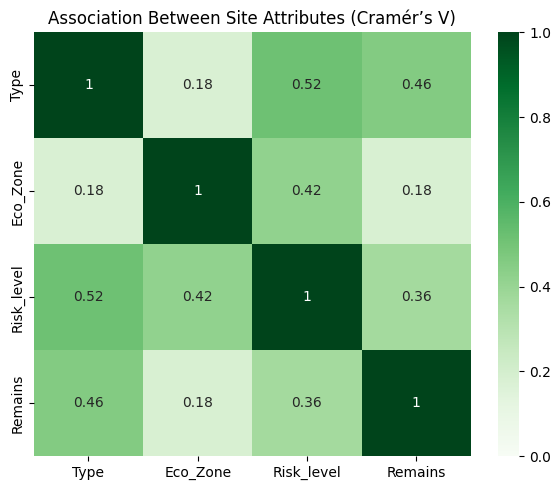

In [30]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cramers_matrix,
    annot=True,
    cmap='Greens',
    vmin=0,
    vmax=1
)

plt.title("Association Between Site Attributes (Cramér’s V)")
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "categorical-associations.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

## 9. Decision Tree Regressor
The features 'Type', 'Subtype', 'Eco_Zone', and 'Remains' are used to predict 'Risk_level'.

In [31]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split

df_new.keys()

Index(['Zone', 'Coord_x', 'Coord_y', 'Accuracy', 'Validation', 'Type',
       'Subtype', 'Eco_Zone', 'Risk_level', 'Cod_Risk', 'Remains', 'lon',
       'lat', 'coord_valid', 'Remains_bin', 'Risk_numeric'],
      dtype='object')

In [32]:
# set the target y (Risk level)
y_reg = df_new['Risk_numeric']

# set the features X 
X = df_new.drop(columns=['Zone', 'Coord_x', 'Coord_y', 'Accuracy', 'Validation', 'Risk_level','Cod_Risk', 'lon',
       'lat', 'coord_valid', 'Remains_bin','Risk_numeric'])

In [33]:
y_reg

0       3
1       3
2       3
3       3
4       3
       ..
3350    1
3351    3
3352    1
3353    1
3354    1
Name: Risk_numeric, Length: 3355, dtype: int64

In [34]:
X

,Type,Subtype,Eco_Zone,Remains
0,Water place,Cistern,Coastal zone and northern tableland,No
1,Settlement,Harbour,Coastal zone and northern tableland,Yes
2,Settlement,Harbour,Coastal zone and northern tableland,Yes
3,Settlement,Fort,Coastal zone and northern tableland,Yes
4,Burial place,Grave(s),Coastal zone and northern tableland,No
...,...,...,...,...
3350,Settlement,Settlement,Coastal zone and northern tableland,Yes
3351,Settlement,Harbour,Coastal zone and northern tableland,Yes
3352,Settlement,Harbour,Coastal zone and northern tableland,No
3353,Settlement,Harbour,Coastal zone and northern tableland,No


In [35]:
# Encode the categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

In [36]:
# Find the best hyperparameter max_depth for the model
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_reg, test_size=0.3, random_state=42)

depths = range(1,20)
scores = []

cv = KFold(n_splits = 4, shuffle=True, random_state=0)

for d in depths:
    dt_reg = DecisionTreeRegressor(max_depth=d, random_state=0)

    score = -cross_val_score(dt_reg, X_train, y_train, scoring='neg_mean_absolute_error', cv = cv).mean()
    scores.append(score) 

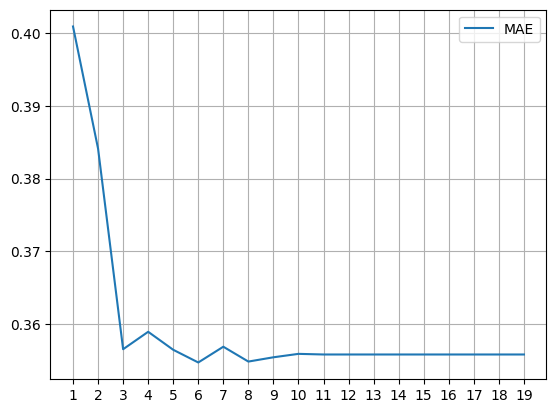

In [37]:
plt.plot(depths, scores, label="MAE")
plt.xticks(ticks=depths)
plt.grid()
plt.legend()

In [38]:
# Use max_depth =6 to train the model and evaluate the performance
final_dt_reg = DecisionTreeRegressor(max_depth=6, random_state=0)
final_dt_reg.fit(X_train, y_train)

y_pred_reg = final_dt_reg.predict(X_test)

from sklearn.metrics import mean_absolute_error,mean_squared_error

mae = mean_absolute_error(y_test, y_pred_reg)
mse = mean_squared_error(y_test, y_pred_reg)
rmse = np.sqrt(mse)
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.35140200424855317
RMSE: 0.4498185273639104


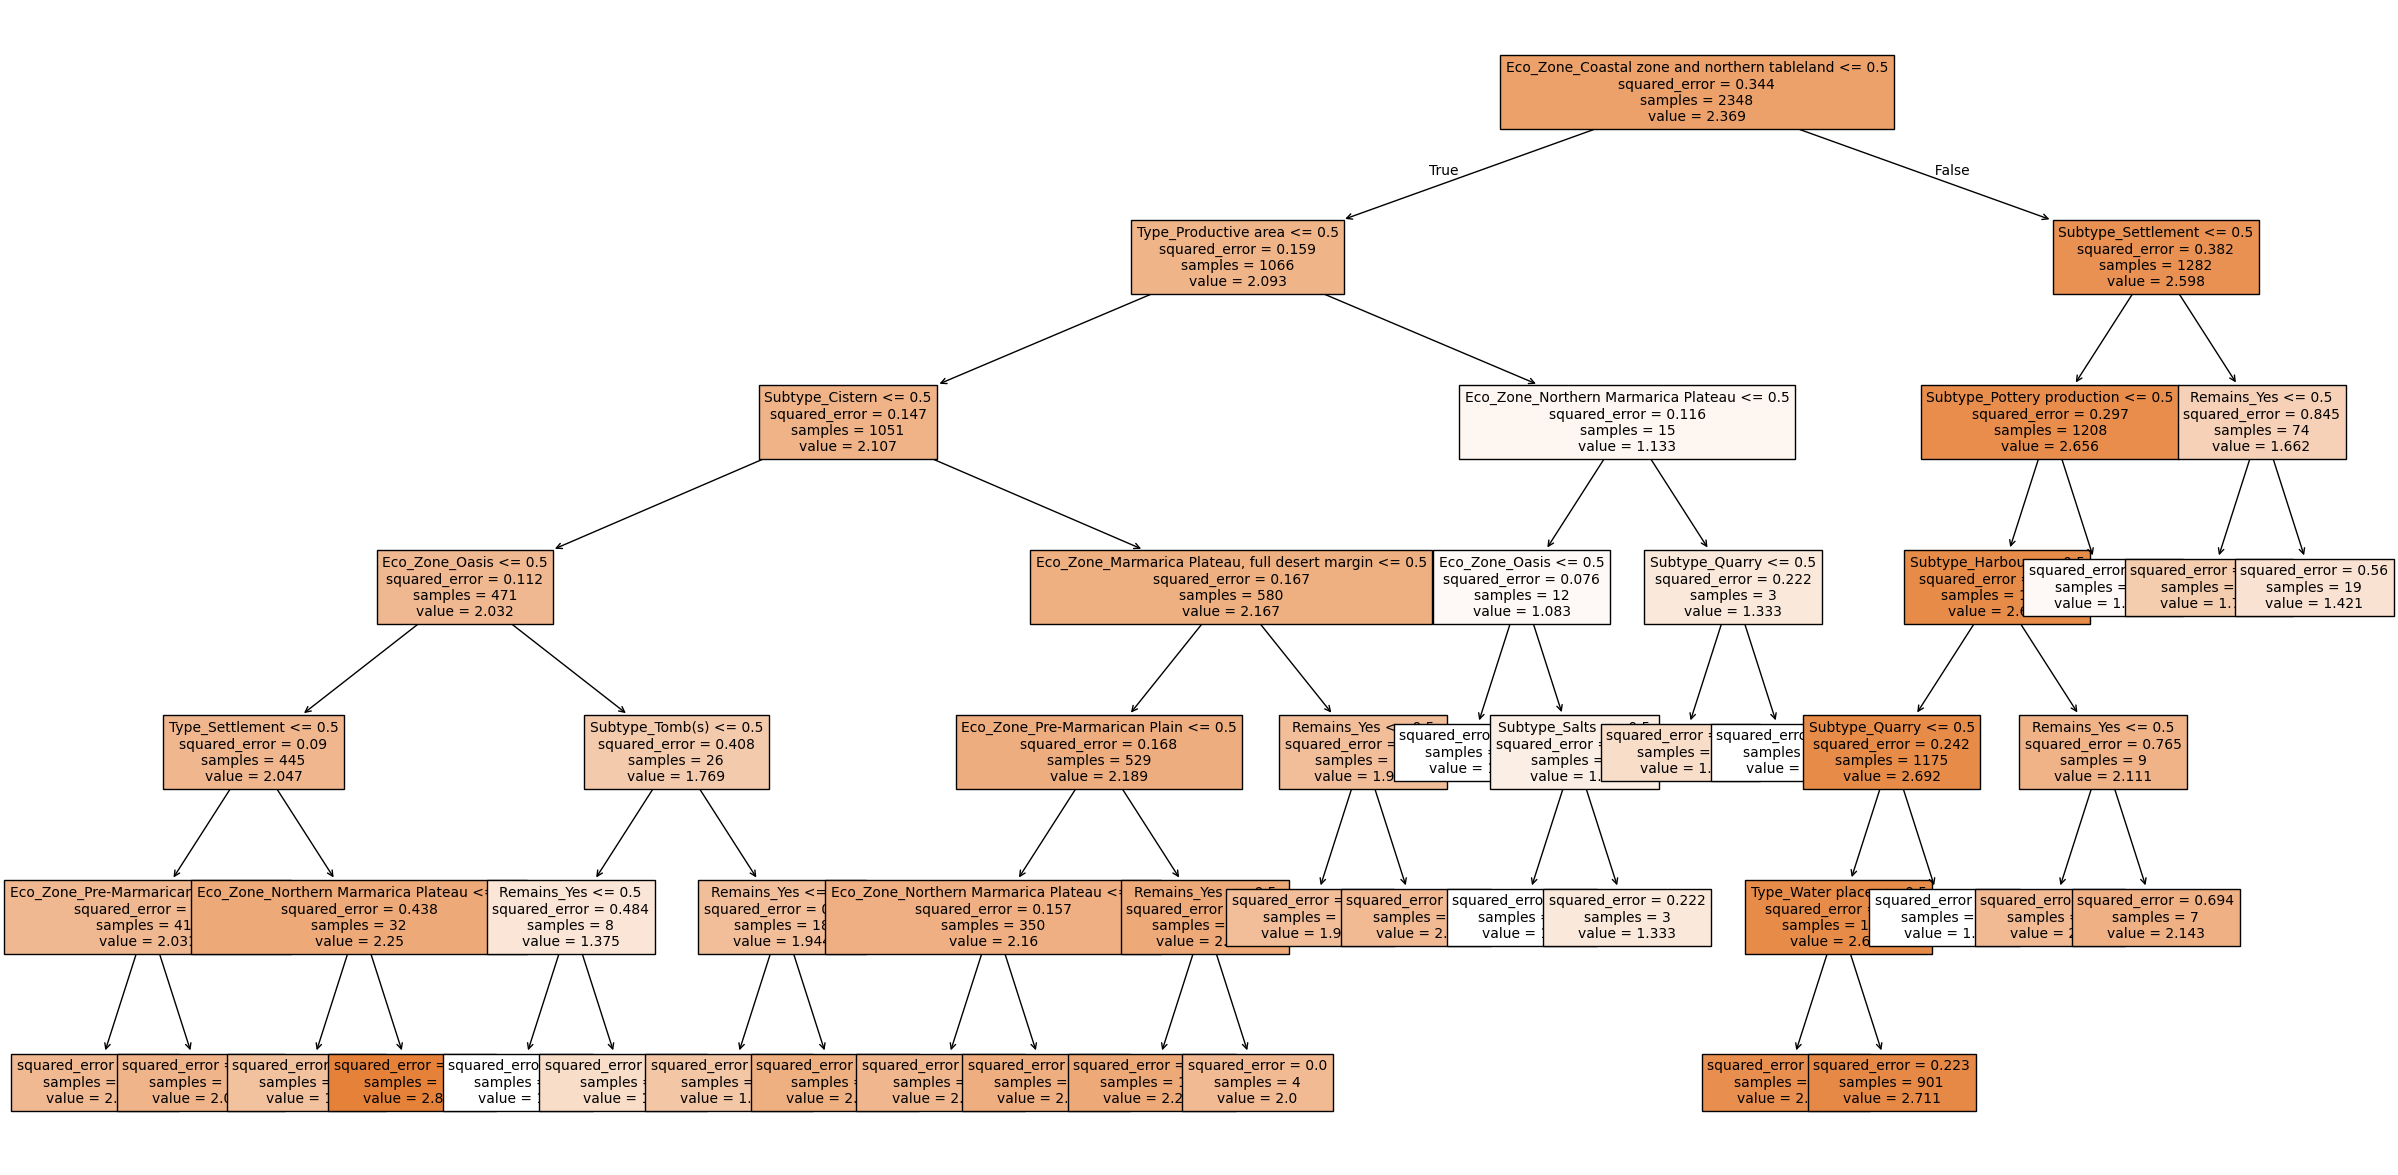

In [39]:
plt.figure(figsize=(30,15))
plot_tree(final_dt_reg, feature_names=X_train.columns,filled=True, fontsize=10)
plt.show()

<Axes: >

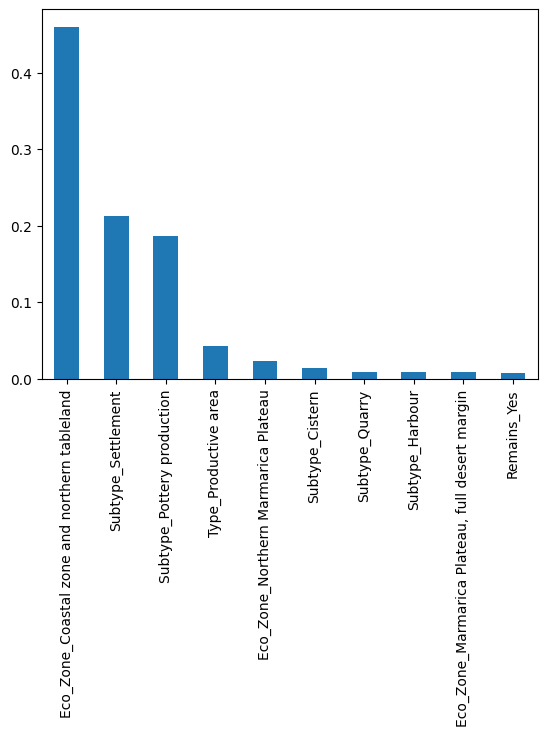

In [40]:
# Visualize the most important features 
importance = pd.Series(
    final_dt_reg.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(10).plot(kind='bar')

In [41]:
# Check for overfitting using train–test error comparison
y_train_pred = final_dt_reg.predict(X_train)
train_mae = mean_absolute_error(y_train, y_train_pred)

print("Train MAE:", train_mae)
print("Test  MAE:",mae)

Train MAE: 0.3459744968266475
Test  MAE: 0.35140200424855317


## 10. Decision Tree Classifier

After revisiting the metadata, "Risk_level" was found to be defined by the type of risk rather than by a numerical scale. 
"Risk_level" is essentially a categorical decision outcome. It is neither a naturally continuous variable nor derived from numerical intensity. Therefore I trained another Decision Tree classifier to compare with the regressor.

In [42]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold #use StratifiedKFold since the classes are imbalanced

y_clf = df_new['Risk_level']

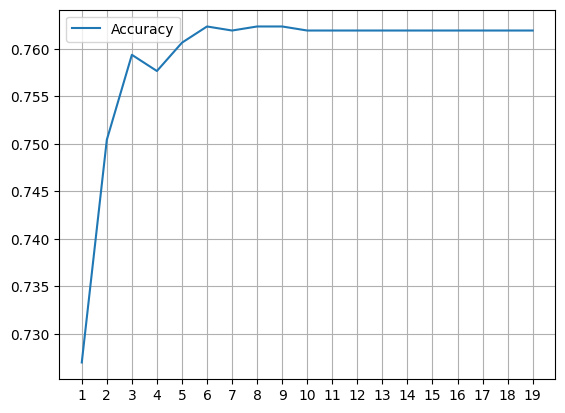

In [43]:
# Find the best hyperparameter max_depth for the model
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_encoded, y_clf, test_size=0.3, random_state=42, stratify=y_clf
)

depths = range(1, 20)
scores_acc = []

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=0)

for d in depths:
    dt_clf = DecisionTreeClassifier(max_depth=d, random_state=0)

    scores_acc.append(cross_val_score(dt_clf, X_train_clf, y_train_clf, scoring='accuracy', cv=cv).mean())

plt.plot(depths, scores_acc, label="Accuracy")
plt.xticks(list(depths))
plt.grid(True)
plt.legend()
plt.show()

In [44]:
# Use max_depth =6 to train the model and evaluate the performance
final_dt_clf = DecisionTreeClassifier(max_depth=6, random_state=0)
final_dt_clf.fit(X_train_clf, y_train_clf)

y_pred_clf = final_dt_clf.predict(X_test_clf)

from sklearn.metrics import classification_report

print(classification_report(y_test_clf, y_pred_clf))

from sklearn.metrics import accuracy_score
error_rate = 1 - accuracy_score(y_test_clf, y_pred_clf)
print(error_rate)

              precision    recall  f1-score   support

        High       0.73      0.86      0.79       426
         Low       0.65      0.63      0.64        59
    Moderate       0.87      0.74      0.80       522

    accuracy                           0.78      1007
   macro avg       0.75      0.74      0.74      1007
weighted avg       0.80      0.78      0.78      1007

0.21549155908639528


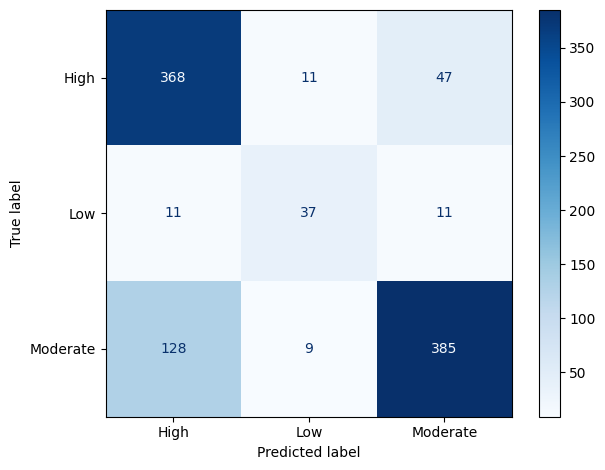

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_estimator(
    final_dt_clf,
    X_test_clf,
    y_test_clf,
    cmap="Blues"
)

disp.figure_.tight_layout()
disp.figure_.savefig(
    RESULTS_DIR / "classifier-confusion-matrix.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

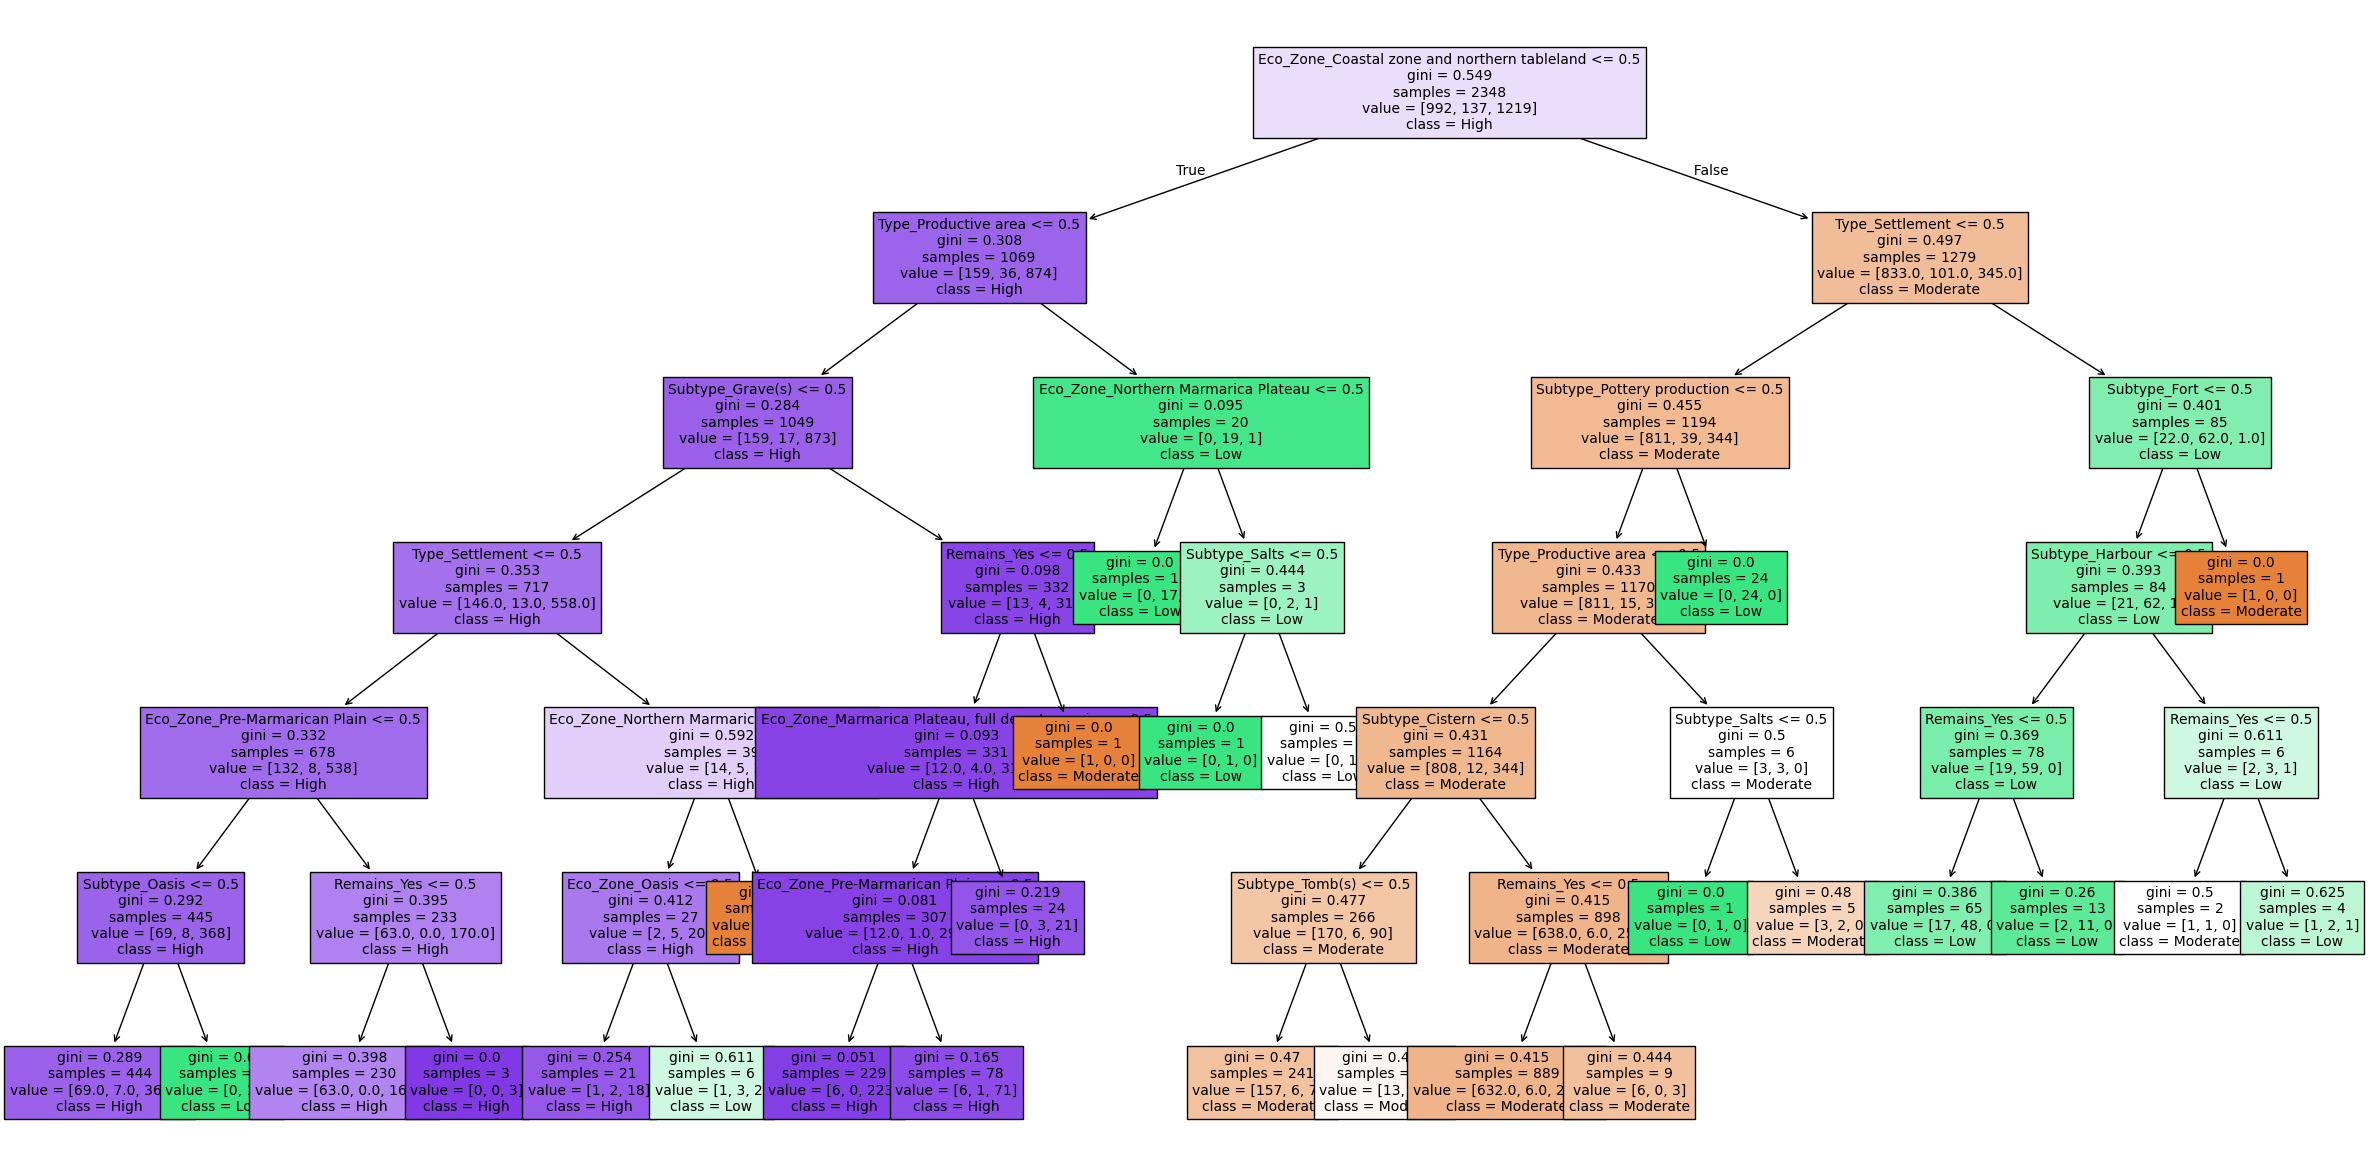

In [46]:
plt.figure(figsize=(30,15))
plot_tree(final_dt_clf, feature_names=X_train_clf.columns, class_names = list(set(y_clf)), filled=True, fontsize=10)
plt.show()


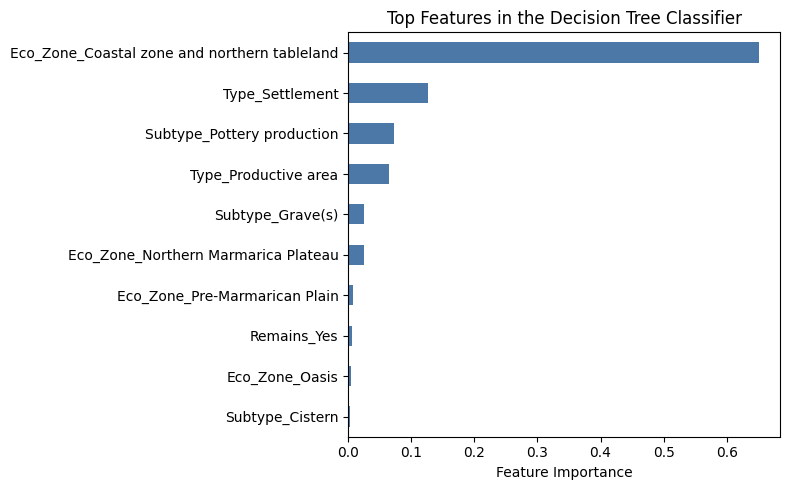

In [47]:
importance = pd.Series(
    final_dt_clf.feature_importances_,
    index=X_train_clf.columns
).sort_values(ascending=False)

ax = importance.head(10).sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    color="#4C78A8"
)

ax.set_title("Top Features in the Decision Tree Classifier")
ax.set_xlabel("Feature Importance")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "classifier-feature-importance.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

In [48]:
# Check for overfitting using train–test accuracy comparison
train_acc = final_dt_clf.score(X_train_clf, y_train_clf)
test_acc = final_dt_clf.score(X_test_clf, y_test_clf)

print(train_acc, test_acc)

0.7691652470187393 0.7845084409136047


## 11. Model Comparison

In [49]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

print("Accuracy:", accuracy_score(y_test_clf, y_pred_clf))
print("Balanced Acc:", balanced_accuracy_score(y_test_clf, y_pred_clf))
print("Macro F1:", f1_score(y_test_clf, y_pred_clf, average="macro"))

Accuracy: 0.7845084409136047
Balanced Acc: 0.7428387673487732
Macro F1: 0.7415705524887235


In [50]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred_reg)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.35140200424855317
RMSE: 0.4498185273639104
R2: 0.4342471145231558


### 11.1 Evaluate rounded regression outputs as classes

To enable a direct comparison between the regression and classification approaches, 
the continuous predictions of the regression model were converted into discrete risk categories.

The regression outputs were rounded to the nearest integer and constrained to the valid class range (1–3). 
The ground-truth labels were also cast to integers to ensure consistency.

Classification metrics, including accuracy and macro F1-score, were then computed, 
and a confusion matrix was used to visualize class-level prediction performance.

Reg-as-class Accuracy: 0.7457795431976166
Reg-as-class Macro F1: 0.6926302979418142


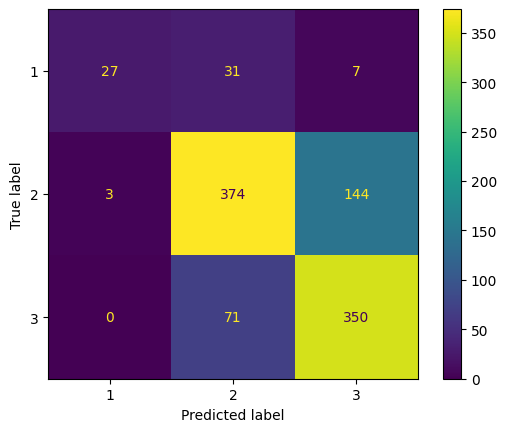

In [51]:
# round regression predictions to 1/2/3
y_pred_reg_round = np.clip(np.round(y_pred_reg), 1, 3).astype(int)

y_true_reg = y_test.astype(int)

from sklearn.metrics import confusion_matrix

print("Reg-as-class Accuracy:", accuracy_score(y_true_reg, y_pred_reg_round))
print("Reg-as-class Macro F1:", f1_score(y_true_reg, y_pred_reg_round, average="macro"))

ConfusionMatrixDisplay(confusion_matrix(y_true_reg, y_pred_reg_round), display_labels=[1,2,3]).plot()

When the regression model predictions were rounded to discrete risk levels, the resulting accuracy (0.75) and macro F1 score (0.69) were consistently lower than those of the direct classification model. The confusion matrix shows that most regression errors occur between adjacent categories, particularly between moderate and high risk levels. 

Given that risk levels are defined as categorical management outcomes derived from discrete risk types rather than from a continuous intensity scale, I think the classifier is more appropriate for this dataset.

## 12. Interpretation and Limitations

The decision-tree classifier is the more appropriate model for this dataset because the target represents categorical heritage-management outcomes derived from discrete risk types, rather than measurements on a naturally continuous scale. Its test accuracy (0.785), balanced accuracy (0.743), and macro F1-score (0.742) were also higher than the classification metrics obtained by rounding the regressor outputs.

Important limitations remain:

- The **Low** class contains only 196 of 3,355 records, creating class imbalance.
- Risk level is an indirect label derived from underlying risk types.
- More than 95% of chronology values are undetermined, preventing reliable temporal analysis.
- The coordinate plots and KDE provide exploratory views rather than formal spatial-statistical inference.
- No external environmental covariates, such as elevation, hydrology, accessibility, or modern land use, were included.
- The results should therefore be interpreted as a methodological exploration, not as operational conservation recommendations.
